# PS-S06E02: CatBoost

This notebook tackles the [**Playground Series – Season 6, Episode 2: Predicting Heart Disease**](https://www.kaggle.com/competitions/playground-series-s6e2), a competition focused on predicting if a patient has heart disease, based on features describing the patient's demographics and selected health metrics.

The task is **binary classification**: predict whether heart disease is **Present** or **Absent**. The leaderboard metric is **ROC AUC**.

CatBoost is a strong baseline for tabular problems and often complements XGBoost/LightGBM in ensembles because it can behave differently on categorical and mixed-type features.

In this notebook we:
- Apply lightweight feature engineering per fold (to avoid leakage)
- Train a **CatBoostClassifier** with stratified cross-validation
- Collect **OOF probabilities** and averaged **test probabilities** for blending/stacking
- Track fold and overall **ROC AUC**

## Install Needed Packages

In [1]:
import os
import gc
import sys
import math
import random
import warnings

# --- Third-party
import numpy as np
import pandas as pd
import catboost as cb
import optuna
import torch
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import RFECV
from catboost import CatBoostClassifier, Pool, EFstrType, EFeaturesSelectionAlgorithm, EShapCalcType

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e02_feature_engineering import FeatureFactory
from ps_s06e02_model_visualizer import ModelVisualizer
from ps_s06e02_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# Target label column for S06E02
TARGET = 'Heart Disease'

# GPU usage (set True only if your environment supports CatBoost GPU)
USE_GPU = False

# Optional: Recursive Feature Elimination
PERFORM_RFE = False

# Optional: Optuna tuning
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1          3.600            2   
1     171                0          0.000            1   
2     151                0          0.000            1   
3     150                0          1.000            2   
4     125                1          3.800            2   

   Number of vessels fluro  Thallium Heart Disease  
0                        2         7      Presence  
1                        0         3    

## Read and Examine the Test Dataset

In [4]:
test_df = helper.read_dataset('test')

TEST DATASET

       id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  \
0  630000   58    1                3  120          288             0   
1  630001   55    0                2  120          209             0   
2  630002   54    1                4  120          268             0   
3  630003   44    0                3  112          177             0   
4  630004   43    1                1  138          267             0   

   EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \
0            2     145                1          0.800            2   
1            0     172                0          0.000            1   
2            0     150                1          0.000            2   
3            0     168                0          0.900            1   
4            0     163                0          1.800            2   

   Number of vessels fluro  Thallium  
0                        3         3  
1                        0         3  
2        

## Feature Engineering Strategy

We apply a small set of feature engineering steps that are safe to run **inside each fold** (to avoid leakage) and compatible with CatBoost:

- `drop_id`: removes `id` and the target column from the feature matrix
- `standard_scaling`: standardizes numeric features
- `interactions`: adds a small set of numeric interaction features

We do **not** one-hot encode categoricals in this notebook. The heart disease dataset uses integer-coded categorical fields (e.g., chest pain type). We pass those columns to CatBoost as categorical features so the model can learn split rules directly.


In [5]:
# Define which feature engineering strategies to use
fe_strategies = [
    'drop_id',
    'cast_categoricals',
    'interactions',
    'numeric_transforms',
    'bins',
    'cat_crosses',
]

In [6]:
print('Performing initial feature engineering.')

# Encode target labels: Presence->1, Absence->0
y = training_df[TARGET].map({'Absence': 0, 'Presence': 1}).astype(np.int8)

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

cat_features = feature_engineer.get_cat_features(X)
print(f'Feature Count: {X.shape[1]}')
print(f'CatBoost categorical features ({len(cat_features)}): {cat_features}')
display(X.head())

Performing initial feature engineering.
Feature Count: 30
CatBoost categorical features (15): ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Age_bin', 'Cholesterol_bin', 'BP_bin', 'ST_depression_bin', 'MaxHR_ratio_bin', 'Vessels_x_Thallium', 'ChestPain_x_SlopeST']


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Theoretical_Max_HR,HR_Deficiency,Cholesterol_Age_Ratio,BP_Age_Factor,Angina_Pain_Interaction,log1p_Cholesterol,ST_depression_is_zero,log1p_ST_depression,MaxHR_ratio,ST_by_MaxHR,Age_bin,Cholesterol_bin,BP_bin,ST_depression_bin,MaxHR_ratio_bin,Vessels_x_Thallium,ChestPain_x_SlopeST
0,58,1,4,152,239,0,0,158,1,3.600,2,2,7,162,4,4.051,8816,4,5.481,0,1.526,0.975,0.023,3,4,6,5,6,2|7,4|2
1,52,1,1,125,325,0,2,171,0,0.000,1,0,3,168,-3,6.132,6500,0,5.787,1,0.000,1.018,0.000,3,9,2,0,7,0|3,1|1
2,56,0,2,160,188,0,2,151,0,0.000,1,0,3,164,13,3.298,8960,0,5.242,1,0.000,0.921,0.000,3,0,6,0,4,0|3,2|1
3,44,0,3,134,229,0,2,150,0,1.000,2,0,3,176,26,5.089,5896,0,5.438,0,0.693,0.852,0.007,2,2,4,2,2,0|3,3|2
4,58,1,4,140,234,0,2,125,1,3.800,2,3,3,162,37,3.966,8120,4,5.460,0,1.569,0.772,0.030,3,3,4,5,1,3|3,4|2


In [7]:
# Categorical columns for this competition (integer-coded)
cat_cols = [
    'Sex',
    'Chest pain type',
    'FBS over 120',
    'EKG results',
    'Exercise angina',
    'Slope of ST',
    'Number of vessels fluro',
    'Thallium',
]

cat_cols = [c for c in cat_cols if c in X.columns]
print(f'Categorical Features: {cat_cols}')

# CatBoost accepts categoricals as either int codes or strings. We keep int codes here.
for c in cat_cols:
    # Ensure clean integer dtype (nullable ints can cause issues)
    X[c] = X[c].astype(int)
    X_test[c] = X_test[c].astype(int)

Categorical Features: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


### Recursive Feature Elimination (RFE)

Optionally run **RFECV** to remove features that do not contribute to ROC AUC.

- This is relatively expensive for boosting models.
- In practice, feature selection often helps less than careful regularization and early stopping.
- Keep this off unless you are explicitly experimenting.


In [8]:
n_jobs = 1 if USE_GPU else -1

optimal_cols = X.columns

if PERFORM_RFE:
    print('Running Recursive Feature Elimination (RFECV)...')

    FS_RANDOM_SEED = seed
    FS_STEPS = 20  # higher = slower, potentially more stable (try 10/20/30)
    FS_EVAL_SPLIT = 0.2  # simple holdout inside selection
    
    # Ensure y is numeric 0/1 (adjust mapping if your y already is numeric)
    if y.dtype == object:
        y_fs = y.map({'Absence': 0, 'Presence': 1}).astype(np.int8)
    else:
        y_fs = y.astype(np.int8)

    # Recreate features using your FeatureFactory (same as training)
    fe_fs = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=FS_RANDOM_SEED)
    X_fs = fe_fs.fit_transform(training_df).drop(columns=[TARGET], errors="ignore")
    cat_features_fs = fe_fs.get_cat_features(X_fs)

    # Train/eval split for feature selection (stratified)
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=1, test_size=FS_EVAL_SPLIT, random_state=FS_RANDOM_SEED)
    tr_idx, va_idx = next(sss.split(X_fs, y_fs))

    X_tr_fs, y_tr_fs = X_fs.iloc[tr_idx], y_fs.iloc[tr_idx]
    X_va_fs, y_va_fs = X_fs.iloc[va_idx], y_fs.iloc[va_idx]

    train_pool_fs = Pool(X_tr_fs, y_tr_fs, cat_features=cat_features_fs)
    eval_pool_fs  = Pool(X_va_fs, y_va_fs, cat_features=cat_features_fs)

    # Base model for selection.
    # You can swap in your tuned params once you have them; keep it modest for speed.
    fs_model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=4000,
        learning_rate=0.05,
        depth=6,
        random_seed=FS_RANDOM_SEED,
        od_type="Iter",
        od_wait=200,
        verbose=200,
        allow_writing_files=False,
    )

    # Select features
    # - RecursiveByShapValues: generally strong, slower
    # - RecursiveByLossFunctionChange: faster, often good enough
    fs_result = fs_model.select_features(
        train_pool_fs,
        eval_set=eval_pool_fs,
        features_for_select=list(range(X_tr_fs.shape[1])),  # select from all features
        num_features_to_select=int(X_tr_fs.shape[1] * 0.80),  # keep 80% (tune: 0.6–0.9)
        steps=FS_STEPS,
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
        shap_calc_type=EShapCalcType.Regular,
        train_final_model=True,
        logging_level="Verbose",
        plot=False
    )

    selected_idx = fs_result["selected_features"]
    optimal_cols = [X_fs.columns[i] for i in selected_idx]

    print(f"Selected {len(optimal_cols)} / {X_fs.shape[1]} features.")
    print("First 30 selected columns:")
    print(optimal_cols[:30])

else:
    optimal_cols = None
    print("Feature selection skipped.")


Feature selection skipped.


### Optuna: Hyperparameter Tuning

This section tunes CatBoost hyperparameters to maximize **ROC AUC** using stratified cross-validation.

- We train with `loss_function='Logloss'` and evaluate with `eval_metric='AUC'`.
- Each trial runs a 5-fold stratified CV loop with feature engineering inside the fold.
- The objective returns mean validation AUC across folds (higher is better).


In [9]:
# Ensure optimal_cols is a standard list for filtering
cols_to_keep = list(optimal_cols) if optimal_cols is not None else None

print(f'Training shape: {X.shape}')
# print(f'Categorical Features: {cat_cols}')
print(f'cols_to_keep: {cols_to_keep}')

def objective(trial):

    params = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'iterations': 2500,
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.08),
        'depth': trial.suggest_int('depth', 4, 7),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 5, 50, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.5, 5.0),
        'border_count': trial.suggest_int('border_count', 64, 128),
        'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 20),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 200, log=True),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 10),
        'bootstrap_type': 'Bernoulli',
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'grow_policy': 'SymmetricTree',
        'auto_class_weights': trial.suggest_categorical('auto_class_weights', [None, 'Balanced', 'SqrtBalanced']),
        'task_type': 'GPU' if USE_GPU else 'CPU',
        'gpu_ram_part': 0.65,
        'metric_period': 20,
        'allow_writing_files': False,
        'random_seed': seed,
        'verbose': 0,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    fold_auc = []

    for train_idx, val_idx in cv.split(training_df, y):
        X_train_fold = training_df.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]

        X_val_fold = training_df.iloc[val_idx]
        y_val_fold = y.iloc[val_idx]

        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        if cols_to_keep is not None:
            final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
            if not final_cols:
                raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
            X_train_trans = X_train_trans[final_cols]
            X_val_trans = X_val_trans[final_cols]

        # Get categorical feature names from the fold's feature engineer
        cat_features_fold = fe_fold.get_cat_features(X_train_trans)
        
        # If you filter columns, keep cat_features consistent
        if cols_to_keep is not None:
            cat_features_fold = [c for c in cat_features_fold if c in final_cols]
        
        train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_features_fold)
        val_pool   = Pool(X_val_trans, y_val_fold,   cat_features=cat_features_fold)

        model = CatBoostClassifier(**params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=200,
            verbose=False
        )
        torch.cuda.synchronize()

        val_prob = model.predict_proba(val_pool)[:, 1]
        fold_auc.append(roc_auc_score(y_val_fold, val_prob))

        del model, train_pool, val_pool
        gc.collect()
        
    return float(np.mean(fold_auc))

Training shape: (630000, 30)
cols_to_keep: None


In [10]:
if PERFORM_OPTUNA_TUNING:
    print('Starting Optuna Optimization (ROC AUC)...')

    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)

    study = optuna.create_study(
        study_name='cb_predicting_heart_disease_optuna',
        direction='maximize',
        pruner=pruner
    )

    study.optimize(
        objective,
        n_trials=50,
        n_jobs=1,
        gc_after_trial=True,
        show_progress_bar=True,
        timeout=18000
    )

    print('Best AUC:', study.best_value)
    print('Best Params:', study.best_params)

    best_params = study.best_params
else:
    # Provide reasonable defaults if you are skipping Optuna
    best_params = {
        'learning_rate': 0.05237349086938242,
        'depth': 4,
        'l2_leaf_reg': 14.548862528318692,
        'random_strength': 2.336999674496351,
        'border_count': 98,
        'one_hot_max_size': 8,
        'min_data_in_leaf': 43,
        'leaf_estimation_iterations': 10,
        'subsample': 0.9588828893476449,
        'auto_class_weights': 'Balanced'
    }
    
    print('Using default params:')
    print(best_params)

[I 2026-02-09 16:01:00,966] A new study created in memory with name: cb_predicting_heart_disease_optuna


Starting Optuna Optimization (ROC AUC)...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-02-09 16:09:58,055] Trial 0 finished with value: 0.9553112781283215 and parameters: {'learning_rate': 0.04074002824042686, 'depth': 5, 'l2_leaf_reg': 19.88422872589924, 'random_strength': 4.755176618621687, 'border_count': 102, 'one_hot_max_size': 10, 'min_data_in_leaf': 39, 'leaf_estimation_iterations': 1, 'subsample': 0.6092910508403336, 'auto_class_weights': 'Balanced'}. Best is trial 0 with value: 0.9553112781283215.
[I 2026-02-09 16:13:33,915] Trial 1 finished with value: 0.955419185413172 and parameters: {'learning_rate': 0.03718267169391129, 'depth': 5, 'l2_leaf_reg': 6.962495500193029, 'random_strength': 2.1542775471270503, 'border_count': 116, 'one_hot_max_size': 20, 'min_data_in_leaf': 17, 'leaf_estimation_iterations': 5, 'subsample': 0.9989519925670174, 'auto_class_weights': None}. Best is trial 1 with value: 0.955419185413172.
[I 2026-02-09 16:17:23,691] Trial 2 finished with value: 0.9553444219555806 and parameters: {'learning_rate': 0.02718024559066525, 'depth': 5

### Model Training: Stratified Cross-Validation

Final training uses **5-fold StratifiedKFold**. Within each fold we:

- Fit the feature engineering pipeline on the training split and transform validation/test (leakage prevention)
- Train a `CatBoostClassifier` with early stopping on validation AUC
- Store **OOF probabilities** and averaged **test probabilities** for ensembling

The overall CV score is computed as ROC AUC on the full OOF vector.


In [11]:
# Cross-Validation Training Loop

cb_tuned_params = {
    **best_params,
    'iterations': 8000,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'bootstrap_type': 'Bernoulli',
    'grow_policy': 'SymmetricTree',
    'allow_writing_files': False,
    'random_seed': seed,
    'verbose': 200,
    'metric_period': 20,
    'task_type': 'GPU' if USE_GPU else 'CPU',
}

print('Final CatBoost CV Training with OOF / Test probabilities')
print('========================================================')
print('Parameters used for training:')
print(cb_tuned_params)

cols_to_keep = list(optimal_cols) if optimal_cols is not None else None

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

eval_results = []
models = []

oof_probs = np.zeros(len(y), dtype=np.float64)
test_probs = np.zeros(len(test_df), dtype=np.float64)

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y)):
    print(f'Starting fold {fold+1}/{n_folds}...')

    X_train_fold = training_df.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]

    X_val_fold = training_df.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)

    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]
        X_test_trans  = X_test_trans[final_cols]

    cat_features_fold = fe_fold.get_cat_features(X_train_trans)
    if cols_to_keep is not None:
        cat_features_fold = [c for c in cat_features_fold if c in final_cols]
    
    train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_features_fold)
    val_pool   = Pool(X_val_trans, y_val_fold,   cat_features=cat_features_fold)
    test_pool  = Pool(X_test_trans,              cat_features=cat_features_fold)

    model = cb.CatBoostClassifier(**cb_tuned_params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=200,
        verbose=200
    )

    eval_results.append(model.get_evals_result())
    models.append(model)

    val_prob = model.predict_proba(val_pool)[:, 1]
    oof_probs[val_idx] = val_prob

    fold_auc = roc_auc_score(y_val_fold, val_prob)
    print(f'Fold {fold+1} ROC AUC: {fold_auc:.6f}')

    test_prob_fold = model.predict_proba(test_pool)[:, 1]
    test_probs += test_prob_fold / n_folds

    del model, train_pool, val_pool
    gc.collect()
    
overall_auc = roc_auc_score(y, oof_probs)
print(f'Overall CV ROC AUC: {overall_auc:.6f}')

Final CatBoost CV Training with OOF / Test probabilities
Parameters used for training:
{'learning_rate': 0.05237349086938242, 'depth': 4, 'l2_leaf_reg': 14.548862528318692, 'random_strength': 2.336999674496351, 'border_count': 98, 'one_hot_max_size': 8, 'min_data_in_leaf': 43, 'leaf_estimation_iterations': 10, 'subsample': 0.9588828893476449, 'auto_class_weights': 'Balanced', 'iterations': 8000, 'loss_function': 'Logloss', 'eval_metric': 'AUC', 'bootstrap_type': 'Bernoulli', 'grow_policy': 'SymmetricTree', 'allow_writing_files': False, 'random_seed': 10301, 'verbose': 200, 'metric_period': 20, 'task_type': 'GPU'}
Starting fold 1/5...
0:	test: 0.9205476	best: 0.9205476 (0)	total: 41.4ms	remaining: 5m 31s
200:	test: 0.9549622	best: 0.9549622 (200)	total: 7.37s	remaining: 4m 46s
400:	test: 0.9555504	best: 0.9555504 (400)	total: 14s	remaining: 4m 25s
600:	test: 0.9558315	best: 0.9558315 (600)	total: 21.4s	remaining: 4m 23s
800:	test: 0.9559856	best: 0.9559856 (800)	total: 27.4s	remaining: 

### Model Evaluation

We evaluate using **ROC AUC**, matching the competition metric. AUC measures how well the model ranks positive cases above negative cases across all possible thresholds.

OOF probabilities are used for an unbiased CV estimate.


## Visualizing Model Performance

We use a few diagnostic plots based on out-of-fold probabilities and per-fold training history.

### Learning Curves (Train vs. Validation AUC)
This plot shows the AUC over boosting iterations for the training and validation sets. A widening gap can indicate overfitting; a flat curve suggests diminishing returns.

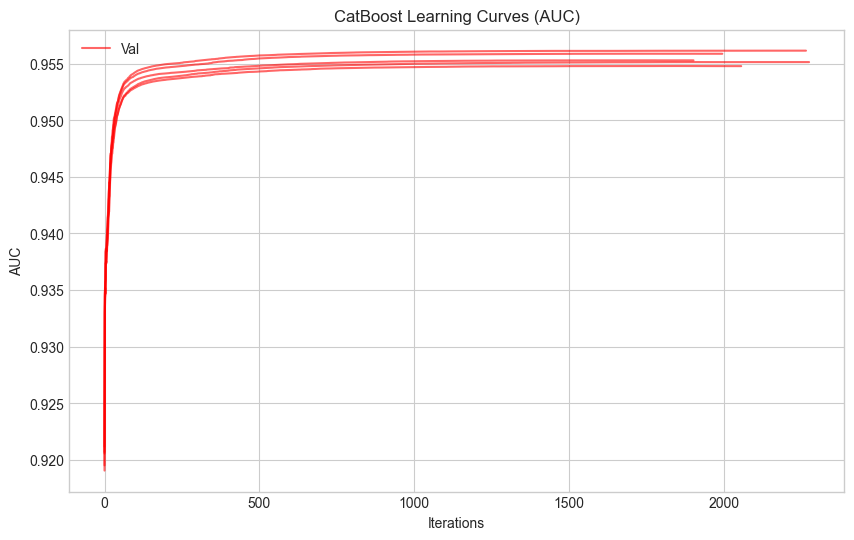

In [12]:
mviz = ModelVisualizer(model_name='CatBoost')

mviz.plot_learning_curves(eval_results, metric='auc')

### Feature Importance
Average feature importance across folds. This is a sanity check (not a causal explanation).

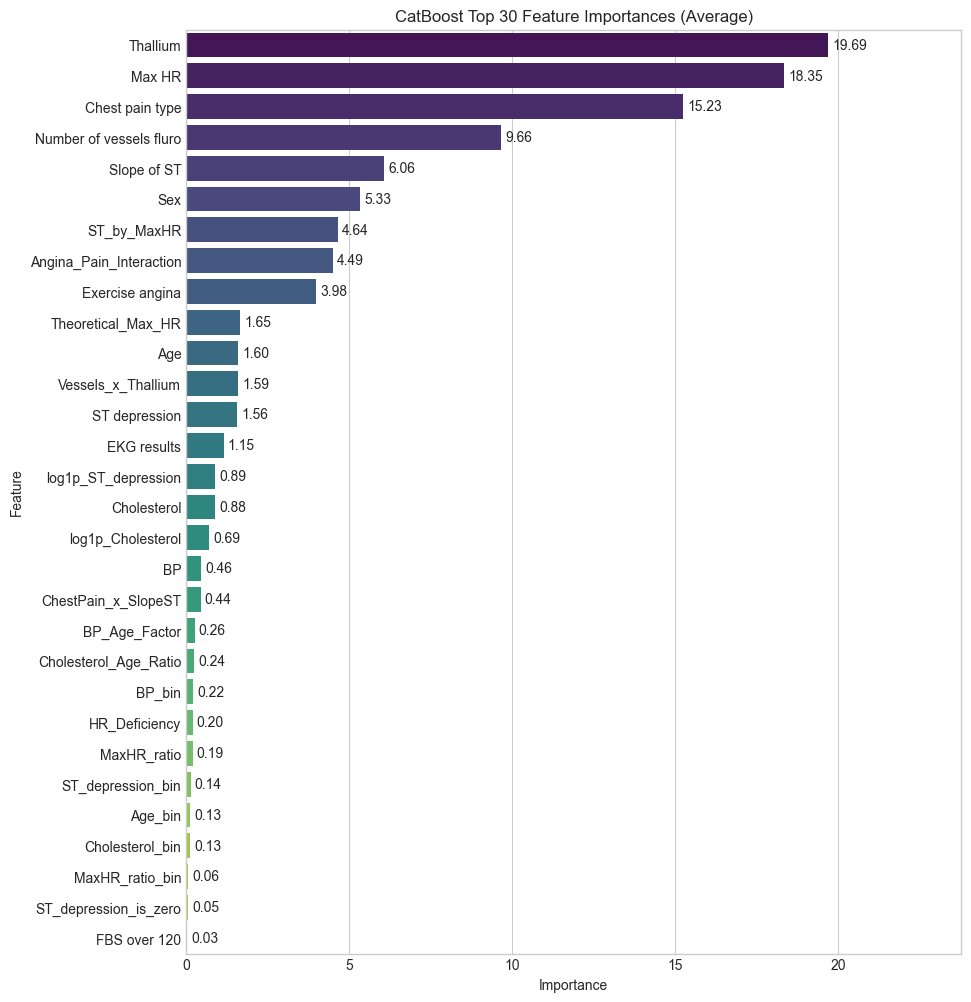

In [13]:
mviz.plot_feature_importance(models, show_values=True)

### ROC Curve (OOF)
The ROC curve is plotted using out-of-fold probabilities. This is a quick visual check of separability and AUC.

<Figure size 800x600 with 0 Axes>

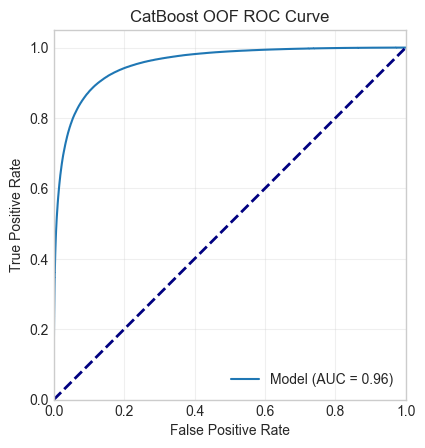

In [14]:
mviz.plot_roc_curve(y_true=y, y_score=oof_probs, title='CatBoost OOF ROC Curve')

### Confusion Matrix (OOF at 0.5 threshold)
AUC is threshold-free, but a confusion matrix at a fixed threshold can help sanity-check error modes.

Normalized confusion matrix


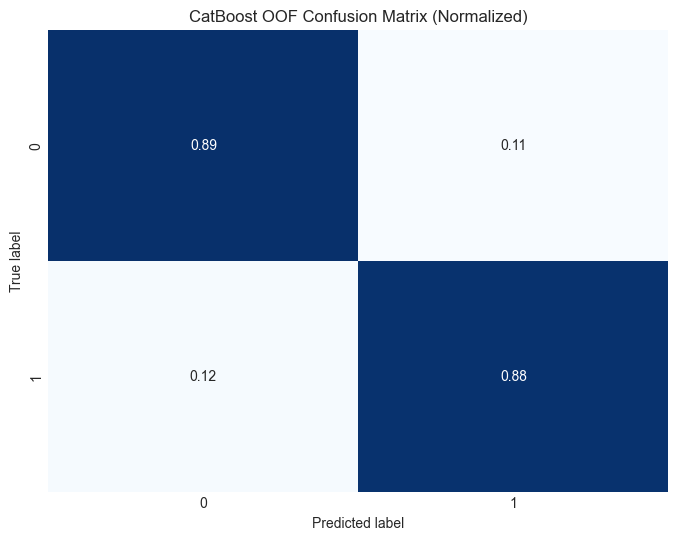

In [15]:
oof_pred_label = (oof_probs >= 0.5).astype(int)
mviz.plot_confusion_matrix(y_true=y, y_pred=oof_pred_label, classes=[0,1], normalize=True, title='CatBoost OOF Confusion Matrix (Normalized)')

## Prepare Submission

We write a submission file using the competition's sample submission schema. The submission value is the **predicted probability** of heart disease presence.

In [16]:
submission_df = helper.read_dataset('submission')

# Identify the prediction column from the sample submission
pred_col = [c for c in submission_df.columns if c != 'id'][0]

submission_df[pred_col] = test_probs

print('SAMPLE SUBMISSION')
display(submission_df.head())

SAMPLE SUBMISSION


,id,Heart Disease
0,630000,0.955
1,630001,0.009
2,630002,0.991
3,630003,0.005
4,630004,0.232


In [17]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

Out-of-fold (OOF) probabilities and averaged test-set probabilities are saved for downstream ensembling (blending/stacking).

Each file contains un-thresholded probabilities, which is essential for ROC AUC evaluation and weighted blending.


In [18]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Save OOF probabilities and Test probabilities for blending/stacking
oof_df = pd.DataFrame({
    'id': training_df['id'].values,
    'prob_catboost': oof_probs,
    'target': y.values
})
oof_df.to_csv(f'{output_dir}/catboost_oof_probs.csv', index=False)

test_prob_df = pd.DataFrame({
    'id': test_df['id'].values,
    'prob_catboost': test_probs
})
test_prob_df.to_csv(f'{output_dir}/catboost_test_probs.csv', index=False)

print(f'Saved for ensembling:\n - {output_dir}/catboost_oof_probs.csv\n - {output_dir}/catboost_test_probs.csv')

Saved for ensembling:
 - predictions/catboost_oof_probs.csv
 - predictions/catboost_test_probs.csv
